# HAR using CNN: split with no leakage

1. **Overlapping windows split randomly** — frame_size=80, hop_size=40 means adjacent windows
   share 50% of their samples; `train_test_split` could put near-duplicates on both sides.
2. **Scaler fit before splitting** — `StandardScaler().fit_transform(X)` saw the test set's
   statistics before any split existed.
3. **Subjects shared between train and test** — `user` was dropped before splitting, so the same
   person's data could appear in both.
4. **Test set used as validation** — `model.fit(..., validation_data=(X_test, y_test))` across 250
   epochs, with the best value reported. That's model selection on the test set.
5. `.head(3555)` drew from 5 of 36 users


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Conv2D, Dense, Dropout, Flatten
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    precision_score,
    recall_score,
    accuracy_score,
    hamming_loss,
    f1_score,
)
from mlxtend.plotting import plot_confusion_matrix

tf.keras.utils.set_random_seed(42)

In [2]:
file = open("../../datasets/WISDM_ar_v1.1/WISDM_ar_v1.1_raw.txt")
lines = file.readlines()

processedList = []
# `user` is kept

for i, line in enumerate(lines):
    try:
        parts = line.strip().rstrip(";").split(",")
        if len(parts) < 6:
            continue
        last = parts[5].split(";")[0]
        if last == "":
            continue
        processedList.append((int(parts[0]), parts[1], float(parts[3]), float(parts[4]), float(last)))
    except (ValueError, IndexError):
        continue

data = pd.DataFrame(processedList, columns=["user", "activity", "x", "y", "z"])
data.shape

(1098203, 5)

In [3]:
ACTIVITY_TO_LABEL = {
    "Jogging": 0,
    "Walking": 1,
    "Upstairs": 2,
    "Downstairs": 3,
    "Sitting": 4,
    "Standing": 5,
}
CLASS_NAMES = list(ACTIVITY_TO_LABEL)

data = data[data["activity"].isin(ACTIVITY_TO_LABEL)].reset_index(drop=True)
data["label"] = data["activity"].map(ACTIVITY_TO_LABEL)
data["activity"].value_counts()

activity
Walking       424397
Jogging       342176
Upstairs      122869
Downstairs    100427
Sitting        59939
Standing       48395
Name: count, dtype: int64


block - same user same activity. Windows will
only ever be cut inside a single block, so no window can span two subjects or two activities

In [4]:
change = (data["user"] != data["user"].shift()) | (data["activity"] != data["activity"].shift())
data["block"] = change.cumsum()
print(f"rows={len(data)}  users={data['user'].nunique()}  blocks={data['block'].nunique()}")

rows=1098203  users=36  blocks=404


## Subject-wise split

matches 27:36

In [5]:
TEST_USERS = list(range(27, 37))
VAL_USERS = [5, 12, 18, 21, 24]

is_test = data["user"].isin(TEST_USERS)
is_val = data["user"].isin(VAL_USERS)
is_train = ~is_test & ~is_val

print("train users:", sorted(data.loc[is_train, "user"].unique()))
print("val users:  ", sorted(data.loc[is_val, "user"].unique()))
print("test users: ", sorted(data.loc[is_test, "user"].unique()))

train users: [np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(10), np.int64(11), np.int64(13), np.int64(14), np.int64(15), np.int64(16), np.int64(17), np.int64(19), np.int64(20), np.int64(22), np.int64(23), np.int64(25), np.int64(26)]
val users:   [np.int64(5), np.int64(12), np.int64(18), np.int64(21), np.int64(24)]
test users:  [np.int64(27), np.int64(28), np.int64(29), np.int64(30), np.int64(31), np.int64(32), np.int64(33), np.int64(34), np.int64(35), np.int64(36)]


scaler after split

In [6]:
train_mean = data.loc[is_train, ["x", "y", "z"]].mean().values
train_std = data.loc[is_train, ["x", "y", "z"]].std().values
print("train mean:", np.round(train_mean, 3), " train std:", np.round(train_std, 3))

data[["x", "y", "z"]] = (data[["x", "y", "z"]].values - train_mean) / train_std

train mean: [0.623 7.215 0.248]  train std: [7.237 6.497 4.933]


In [7]:
Fs = 20
frame_size = Fs * 4  # 80
hop_size = Fs * 2  # 40

def make_windows(df, frame_size, hop_size):
    frames, labels, users = [], [], []
    for _, block in df.groupby("block", sort=False):
        xyz = block[["x", "y", "z"]].values
        if len(xyz) < frame_size:
            continue
        label = block["label"].iloc[0]
        user = block["user"].iloc[0]
        for start in range(0, len(xyz) - frame_size + 1, hop_size):
            frames.append(xyz[start : start + frame_size])
            labels.append(label)
            users.append(user)
    return np.asarray(frames, dtype=np.float32), np.asarray(labels), np.asarray(users)


splits = {}
for name, mask in (("train", is_train), ("val", is_val), ("test", is_test)):
    X, y, users = make_windows(data[mask], frame_size, hop_size)
    X = X[..., np.newaxis]
    splits[name] = (X, y, users)
    counts = np.bincount(y, minlength=len(CLASS_NAMES))
    print(f"{name:<5} windows={len(X):>6}  class counts={dict(zip(CLASS_NAMES, counts.tolist()))}")

X_train, y_train, u_train = splits["train"]
X_val, y_val, u_val = splits["val"]
X_test, y_test, u_test = splits["test"]

X_train.shape, X_val.shape, X_test.shape

train windows= 15251  class counts={'Jogging': 4904, 'Walking': 6136, 'Upstairs': 1675, 'Downstairs': 1210, 'Sitting': 790, 'Standing': 536}
val   windows=  3783  class counts={'Jogging': 1303, 'Walking': 1345, 'Upstairs': 383, 'Downstairs': 361, 'Sitting': 186, 'Standing': 205}
test  windows=  7817  class counts={'Jogging': 2264, 'Walking': 3037, 'Upstairs': 835, 'Downstairs': 762, 'Sitting': 487, 'Standing': 432}


((15251, 80, 3, 1), (3783, 80, 3, 1), (7817, 80, 3, 1))

In [8]:
overlap = (set(u_train) & set(u_test)) | (set(u_train) & set(u_val)) | (set(u_val) & set(u_test))
assert not overlap, f"subject overlap between splits: {overlap}"
print("subject-disjoint check passed:", len(set(u_train)), "train /", len(set(u_val)), "val /", len(set(u_test)), "test users")

subject-disjoint check passed: 21 train / 5 val / 10 test users


In [9]:
model = Sequential()
model.add(Conv2D(32, (2, 2), activation="relu", input_shape=X_train[0].shape))
model.add(Dropout(0.1))

model.add(Conv2D(64, (2, 2), activation="relu"))
model.add(Dropout(0.2))

model.add(Flatten())

model.add(Dense(128, activation="relu"))
model.add(Dropout(0.5))

model.add(Dense(len(CLASS_NAMES), activation="softmax"))

model.compile(
    optimizer=Adam(learning_rate=0.003),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"],
)
model.summary()

C:\Users\amanb\PycharmProjects\arsu-labs-action-recognition\.venv\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 79, 2, 32)      │           160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 79, 2, 32)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 78, 1, 64)      │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 78, 1, 64)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 4992)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       639,104 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 6)              │           774 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 648,294 (2.47 MB)

 Trainable params: 648,294 (2.47 MB)

 Non-trainable params: 0 (0.00 B)

In [10]:
early_stop = EarlyStopping(
    monitor="val_accuracy",
    patience=20,
    restore_best_weights=True,
    verbose=1,
)

history = model.fit(
    X_train,
    y_train,
    epochs=100,
    batch_size=32,
    validation_data=(X_val, y_val),
    callbacks=[early_stop],
    verbose=2,
)

Epoch 1/100


477/477 - 6s - 13ms/step - accuracy: 0.8245 - loss: 0.4887 - val_accuracy: 0.7235 - val_loss: 0.7594


Epoch 2/100


477/477 - 4s - 9ms/step - accuracy: 0.9070 - loss: 0.2457 - val_accuracy: 0.7285 - val_loss: 0.7596


Epoch 3/100


...

477/477 - 7s - 15ms/step - accuracy: 0.9881 - loss: 0.0433 - val_accuracy: 0.7394 - val_loss: 1.7615


Epoch 27/100


477/477 - 10s - 21ms/step - accuracy: 0.9884 - loss: 0.0384 - val_accuracy: 0.6545 - val_loss: 2.6501


Epoch 27: early stopping


Restoring model weights from the end of the best epoch: 7.


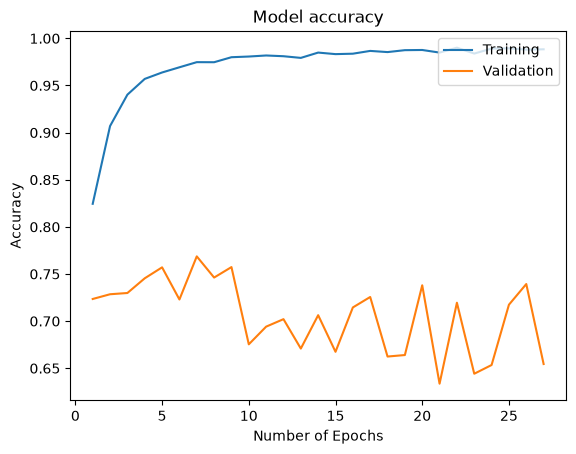

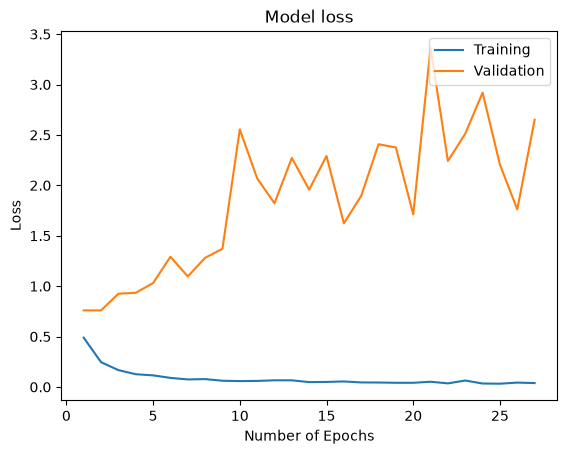

In [11]:
def plot_learningCurve(history):
    epochs_ran = len(history.history["accuracy"])
    epoch_range = range(1, epochs_ran + 1)
    plt.plot(epoch_range, history.history["accuracy"])
    plt.plot(epoch_range, history.history["val_accuracy"])
    plt.title("Model accuracy")
    plt.ylabel("Accuracy")
    plt.xlabel("Number of Epochs")
    plt.legend(["Training", "Validation"], loc="upper right")
    plt.show()

    plt.plot(epoch_range, history.history["loss"])
    plt.plot(epoch_range, history.history["val_loss"])
    plt.title("Model loss")
    plt.ylabel("Loss")
    plt.xlabel("Number of Epochs")
    plt.legend(["Training", "Validation"], loc="upper right")
    plt.show()


plot_learningCurve(history)

## Evaluation on 27 - 36

  1/245 ━━━━━━━━━━━━━━━━━━━━ 33s 138ms/step

  8/245 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step   

 15/245 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step

 23/245 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step

 32/245 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step

...

218/245 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step

230/245 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step

242/245 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step

245/245 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step

245/245 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step


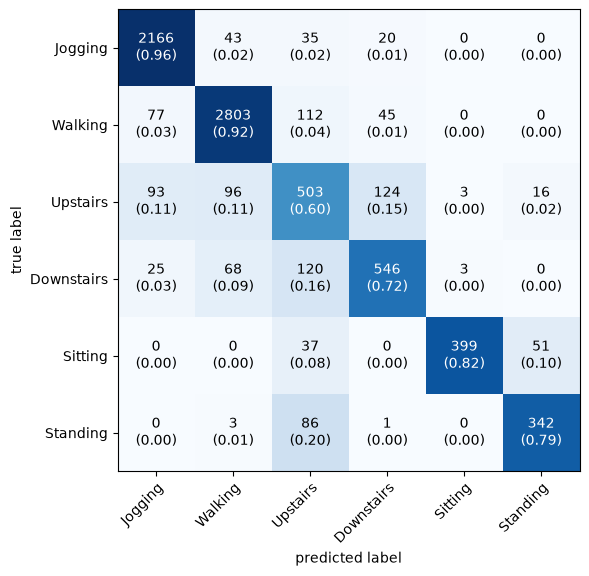

In [12]:
y_pred = np.argmax(model.predict(X_test), axis=-1)
mat = confusion_matrix(y_test, y_pred)
plot_confusion_matrix(conf_mat=mat, class_names=CLASS_NAMES, show_normed=True, figsize=(6, 6))
plt.show()

In [13]:
print("Precision Score : ", np.round(precision_score(y_test, y_pred, average=None), 4))
print("Recall Score    : ", np.round(recall_score(y_test, y_pred, average=None), 4))
print("Accuracy Score  : ", accuracy_score(y_test, y_pred, normalize=True))
print("Macro F1        : ", f1_score(y_test, y_pred, average="macro"))
print("Hamming Loss    : ", hamming_loss(y_test, y_pred))
print()
print(classification_report(y_test, y_pred, target_names=CLASS_NAMES, digits=4))

Precision Score :  [0.9174 0.9303 0.5633 0.7418 0.9852 0.8362]
Recall Score    :  [0.9567 0.923  0.6024 0.7165 0.8193 0.7917]
Accuracy Score  :  0.864653959319432
Macro F1        :  0.8137240701185813
Hamming Loss    :  0.135346040680568

              precision    recall  f1-score   support

     Jogging     0.9174    0.9567    0.9366      2264
     Walking     0.9303    0.9230    0.9266      3037
    Upstairs     0.5633    0.6024    0.5822       835
  Downstairs     0.7418    0.7165    0.7290       762
     Sitting     0.9852    0.8193    0.8946       487
    Standing     0.8362    0.7917    0.8133       432

    accuracy                         0.8647      7817
   macro avg     0.8290    0.8016    0.8137      7817
weighted avg     0.8672    0.8647    0.8652      7817

